In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
drive.mount('/content/drive')

filepath = "/content/drive/MyDrive/Capstone/answers_clean.csv"
answers = pd.read_csv(filepath)

answers

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Furry-01,Furry-02,Furry-03,Furry-04,Furry-05,Furry-06,Furry-07,Furry-08,Furry-09,Furry-10,...,Transphobic_id,Politics,Location,Medium,Furry_unfavorability_raw,Homophobia_raw,Transphobia_raw,Furry_unfavorability_cat,Homophobia_cat,Transphobia_cat
0,2.0,3.0,4.0,2.0,2.0,2.0,2.0,5.0,3.0,2.0,...,Disagree,Moderate left,"Online or sent to me, and I'm taking this surv...",On SurveySwap.io,2.550000,1.20,1.545455,3.0,1.0,2.0
1,5.0,3.0,5.0,3.0,3.0,3.0,5.0,5.0,3.0,3.0,...,Disagree,Moderate left,"Online or sent to me, and I'm taking this surv...",On SurveySwap.io,3.150000,1.30,2.727273,3.0,1.0,3.0
2,4.0,3.0,3.0,4.0,4.0,3.0,2.0,2.0,1.0,4.0,...,Disagree,Moderate left,"Online or sent to me, and I'm taking this surv...",On a Reddit post,3.700000,1.35,1.500000,4.0,1.0,2.0
3,2.0,4.0,5.0,1.0,2.0,3.0,4.0,3.0,4.0,2.0,...,Disagree,Moderate left,"Online or sent to me, and I'm taking this surv...",On a Reddit post,2.150000,1.15,1.409091,2.0,1.0,1.0
4,1.0,3.0,4.0,1.0,2.0,4.0,4.0,5.0,4.0,2.0,...,Disagree,Moderate right,"Online or sent to me, and I'm taking this surv...",On a Reddit post,2.400000,1.85,1.818182,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,1.0,3.0,5.0,1.0,2.0,5.0,3.0,3.0,5.0,2.0,...,Disagree,Far left,"Online or sent to me, and I'm taking this surv...",On a Reddit post,1.950000,1.15,1.545455,2.0,1.0,2.0
204,1.0,4.0,5.0,1.0,1.0,5.0,5.0,5.0,5.0,1.0,...,Disagree,Far left,"Online or sent to me, and I'm taking this surv...",On a Reddit post,1.150000,1.30,1.000000,1.0,1.0,1.0
205,2.0,NaN,3.0,2.0,4.0,3.0,3.0,4.0,3.0,3.0,...,Unsure,Center,None of the above,None of the above,3.052632,2.80,3.000000,3.0,3.0,3.0
206,2.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,4.0,...,Disagree,Moderate left,"Online or sent to me, and I'm taking this surv...",On a Reddit post,3.000000,1.45,1.818182,3.0,1.0,2.0


Edited Gemini:

In [ ]:
class OrdinalClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        # Ensure input data is valid
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        if self.n_classes_ < 2:
            raise ValueError("OrdinalClassifier needs at least 2 classes.")

        # We need K-1 classifiers for K classes
        self.clfs_ = []

        for i in range(self.n_classes_ - 1):
            # Create a binary target: 1 if y is greater than the current class threshold, else 0
            binary_y = (y > self.classes_[i]).astype(int)

            # Clone the base estimator to keep them independent
            clf = clone(self.base_estimator)
            clf.fit(X, binary_y)
            self.clfs_.append(clf)

        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        X = check_array(X)

        # Get the threshold probabilities: P(Y > c_i)
        # We extract the probability of class 1 (column 1) from each binary classifier
        clfs_probs = np.column_stack([clf.predict_proba(X)[:, 1] for clf in self.clfs_])

        # Compute individual ordinal class probabilities
        # P(Y = c_0) = 1 - P(Y > c_0)
        # P(Y = c_i) = P(Y > c_{i-1}) - P(Y > c_i)
        # P(Y = c_K) = P(Y > c_{K-1})
        probs = np.empty((X.shape[0], self.n_classes_))

        probs[:, 0] = 1.0 - clfs_probs[:, 0]
        for i in range(1, self.n_classes_ - 1):
            probs[:, i] = clfs_probs[:, i - 1] - clfs_probs[:, i]
        probs[:, -1] = clfs_probs[:, -1]

        # Clip any minor floating point anomalies to keep probabilities between [0, 1]
        return np.clip(probs, 0, 1)

    def predict(self, X):
        # The class with the highest combined probability wins
        check_is_fitted(self)
        X = check_array(X)

        # 1. Get the index of the highest probability [0, 1, 2, 3]
        predicted_indices = np.argmax(self.predict_proba(X), axis=1)

        # 2. Map those indices back to your true classes [1, 2, 3, 4]
        return self.classes_[predicted_indices]

Edited Gemini:

In [ ]:
def macro_averaged_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    distinct_classes = np.unique(y_true)
    mae_per_class = []

    for c in distinct_classes:
        # Isolate only the respondents who actually belong to class 'c'
        mask = (y_true == c)

        if np.sum(mask) > 0:
            class_mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
            mae_per_class.append(class_mae)

    # Return the unweighted average of the MAEs across all classes
    return np.mean(mae_per_class)

In [ ]:
# Drop all rows with missing favorability assessments. These represent
# respondents who responded to no questions in at least one entire section.
answers = answers.dropna(subset = [
    "Furry_unfavorability_cat", "Homophobia_cat", "Transphobia_cat"])
# Set unresponded questions to 0 so non-response is a distinct category instead
# of being ignored or causing errors.
answers = answers.fillna(0)

predict_furry = answers[
    [f"Homop-{i:02d}" for i in range(1, 21)] +
    [f"Trans-{i:02d}" for i in range(1, 23)] +
    ["Furry_unfavorability_cat"]
]

predict_gay = answers[
    [f"Furry-{i:02d}" for i in range(1, 24)] +
    ["Homophobia_cat"]
]

predict_trans = answers[
    [f"Furry-{i:02d}" for i in range(1, 24)] +
    ["Transphobia_cat"]
]

tasks = {
    "Furry": (predict_furry, "Furry_unfavorability_cat"),
    "Gay": (predict_gay, "Homophobia_cat"),
    "Trans": (predict_trans, "Transphobia_cat")
}

classifiers = {
    "rf": RandomForestClassifier(random_state = 42),
    "lr": LogisticRegression(max_iter = 1000, random_state = 42),
    "hgb": HistGradientBoostingClassifier(random_state = 42),
    "xgb": XGBClassifier(random_state = 42)
}

In [ ]:
def classify_something(task, classifier):
  # Predict
  X = tasks[task][0].drop(tasks[task][1], axis = 1)
  y = tasks[task][0][tasks[task][1]]

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size = 0.25, stratify = y, random_state = 42)

  ordinal_model = OrdinalClassifier(base_estimator=classifier)
  ordinal_model.fit(X_train, y_train)

  y_pred = ordinal_model.predict(X_test)

  y_test_vs_pred = pd.DataFrame({
      "Actual": y_test,
      "Predicted": y_pred
  })

  # Plot
  cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4])
  cm_percent = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] * 100
  plt.figure(figsize=(8, 6))

  sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4],
    cbar_kws={'label': 'Percentage of True Class (%)'}
  )

  plt.gca().invert_yaxis()

  plt.title(f'Ordinal Alignment: True vs. Predicted {task} Favorability', fontsize=14, pad=15)
  plt.xlabel('Predicted Sentiment Level', fontsize=12, labelpad=10)
  plt.ylabel('True Sentiment Level', fontsize=12, labelpad=10)

  plt.tight_layout()
  plt.show()

  # # debugging
  # print(np.unique(y_test, return_counts=True))
  # print(np.unique(y_train, return_counts=True))

  return y_test, y_pred

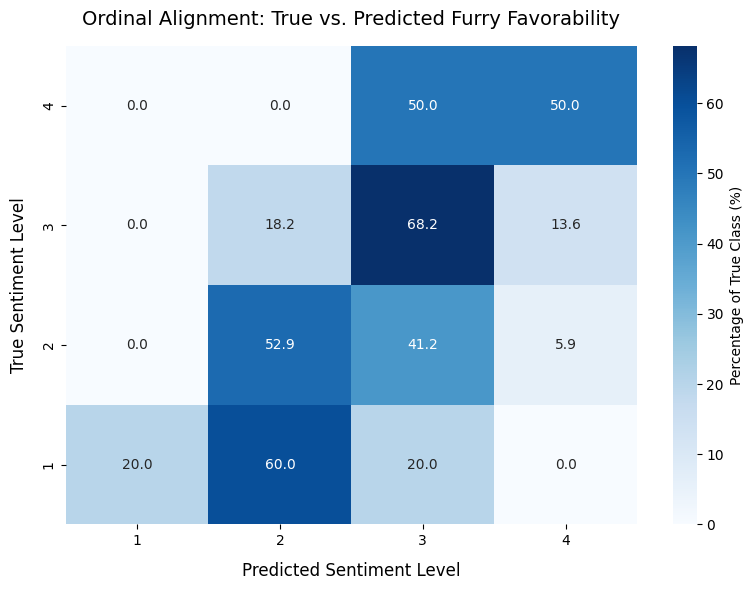

np.float64(0.5868983957219251)

In [ ]:
furry = classify_something("Furry", classifiers["rf"])
macro_averaged_mae(furry[0], furry[1])

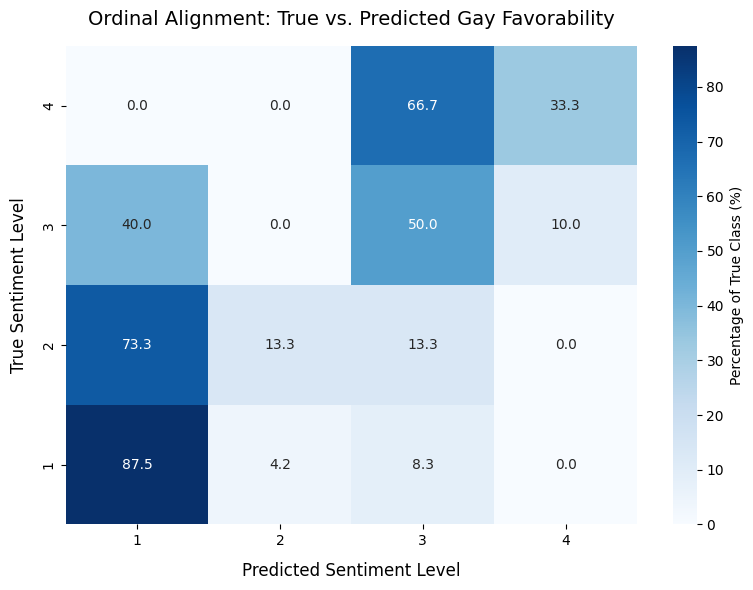

np.float64(0.5868983957219251)

In [ ]:
gay = classify_something("Gay", classifiers["rf"])
macro_averaged_mae(furry[0], furry[1])

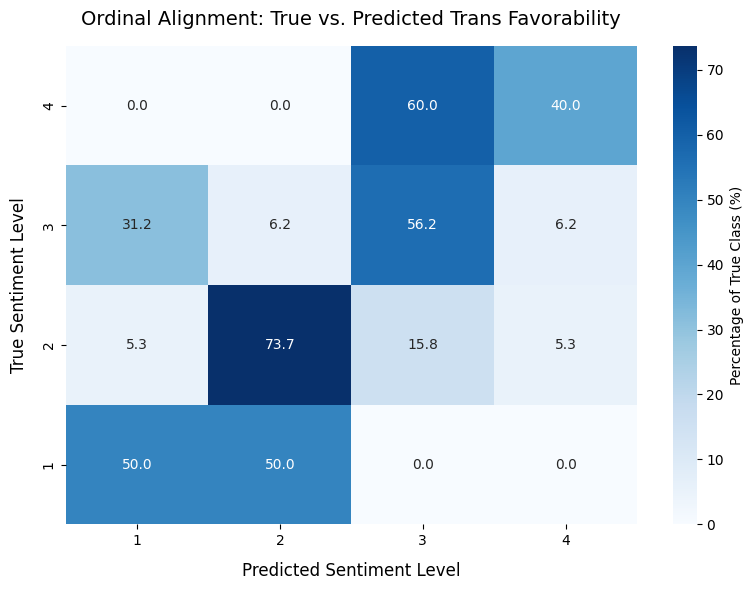

np.float64(0.5868983957219251)

In [ ]:
trans = classify_something("Trans", classifiers["rf"])
macro_averaged_mae(furry[0], furry[1])

In [ ]:
furry_prediction = pd.DataFrame({
    "Actual": furry[0],
    "Predicted": furry[1]
})

furry_prediction

,Actual,Predicted
108,2.0,2.0
106,1.0,1.0
130,4.0,4.0
203,2.0,2.0
0,3.0,2.0
4,2.0,3.0
187,3.0,4.0
152,3.0,3.0
60,2.0,2.0
21,3.0,3.0


In [ ]:
furry_prediction.to_csv("/content/drive/MyDrive/Capstone/predictions.csv", index = False)